In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/churn_clean.csv')
print(df.shape)
df.head()

(7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,1,0,0,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,1,0,34,1,1,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,1,0,2,1,0,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,1,0,45,0,1,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,1,0,2,1,0,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [2]:
X = df.drop(columns='Churn')
y = df['Churn']

print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (5634, 30)
Test: (1409, 30)


In [4]:
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [6]:
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print(scale)

2.766042780748663


In [7]:
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1036
           1       0.56      0.70      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



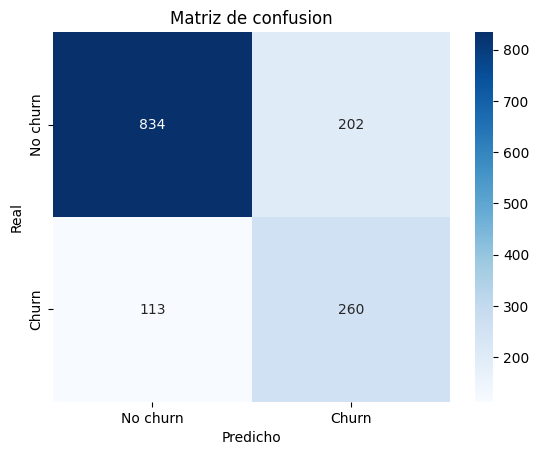

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No churn', 'Churn'],
            yticklabels=['No churn', 'Churn'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion')
plt.show()